<a href="https://colab.research.google.com/github/lt33tx/Landon_Tinch_DTSC3020_Fall2025-/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [1]:
# importing all the libraries we need for data handling, modeling, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

# load the dataset from a csv file into a dataframe
df = pd.read_csv('car_purchase_data.csv')

# show first few rows just to see what the data looks like
display(df.head())

# print basic info about the dataset (columns, types, missing values, etc)
print("\nDataset Info:")
df.info()

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   User ID    400 non-null    int64 
 1   Gender     400 non-null    object
 2   Age        400 non-null    int64 
 3   Salary     400 non-null    int64 
 4   Purchased  400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


### Step 2: Split features and target

In [2]:
# selecting the features (Age and Salary) and converting to numpy array
X = df[['Age', 'Salary']].values

# selecting the target variable (Purchased)
y = df['Purchased'].values

# printing shape of X to see how many rows and features we got
print(f"Shape of Features (X): {X.shape}")

# printing shape of y to check number of labels
print(f"Shape of Target (y): {y.shape}")

Shape of Features (X): (400, 2)
Shape of Target (y): (400,)


### Step 3: Train/Test Split

In [3]:
# split the dataset into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# print how many rows ended up in each set
print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 300 rows
Testing data size: 100 rows


### Step 4: Feature Scaling

In [4]:
# scale the data so features are on the same scale (helps model perform better)
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

print(X_train[:3])

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]]


### Step 5: Train Logistic Regression Model

In [5]:
# train a logistic regression model and look at its learned weights
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

print(f"Model Coefficients (Age, Salary): {classifier.coef_}")
print(f"Model Intercept: {classifier.intercept_}")

Model Coefficients (Age, Salary): [[2.07665837 1.11008221]]
Model Intercept: [-0.95217247]


### Step 6: Predict and Evaluate

Accuracy Score: 89.00%
[[65  3]
 [ 8 24]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



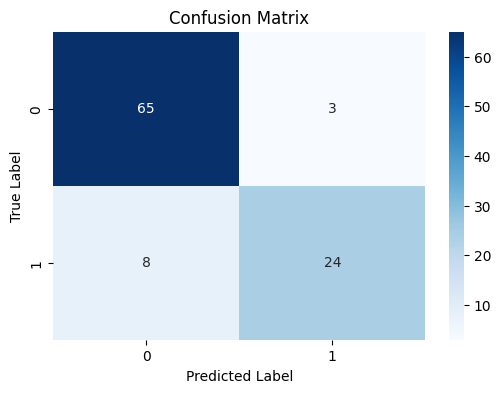

In [6]:
# make predictions and evaluate how well the model did
y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy Score: {accuracy * 100:.2f}%")

print(conf_matrix)

print(class_report)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Step 7: Visualization of Decision Regions

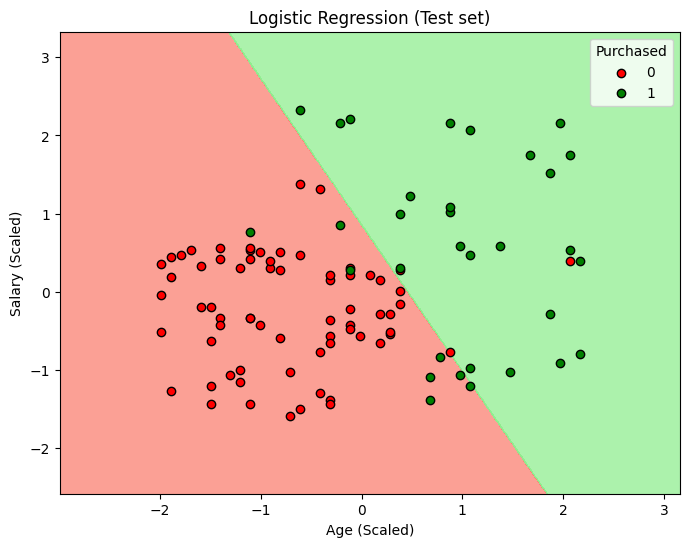

In [7]:
# visualize the decision boundary and how the model splits the classes
X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

plt.figure(figsize=(8, 6))

plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('salmon', 'lightgreen')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color = ListedColormap(('red', 'green'))(i), label = j, edgecolors='black')

plt.title('Logistic Regression (Test set)')
plt.xlabel('Age (Scaled)')
plt.ylabel('Salary (Scaled)')
plt.legend(title='Purchased')
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

**1. Logistic regression outputs probabilities — why can it still be used for classification?**

 Even though logistic regression gives out a probability between 0 and 1 using the sigmoid function, it can still be used for classification because it uses a cutoff point called a threshold. Usually that threshold is 0.5. So if the model gives a probability of 0.5 or higher, it predicts class 1, which is Purchased. If it is below 0.5, it predicts class 0, which is Not Purchased. So basically it turns a probability into a yes or no classification.

**2. Based on your model, which customers are more likely to purchase a car?**

Based on the coefficients from Step 5, both Age and Salary have positive values, which means older customers and customers with higher salaries are more likely to buy a car. Since the data was standardized, we can compare the coefficients directly, and Age seems to matter more than Salary because its coefficient is bigger. So overall, older people with higher salaries are the most likely to purchase.

**3. What factors might cause low accuracy in this task?**

Even though the model got 89% accuracy, the 11% of mistakes probably happened because logistic regression has limits. It works best when the data can be separated with a straight line, but real buying behavior is usually more complicated than that. For example, the relationship between age, salary, and buying a car might not be perfectly linear. Also, some customers can have really similar profiles but still make different choices, which makes the boundary between classes kind of messy and harder for the model to figure out.

**4. Propose additional features or preprocessing steps that could improve accuracy.**

One thing that could help is adding more features. For example, the Gender column was removed, but if it was coded as 1 and 0, it might give the model a little more information. Other features like credit score, family size, or whether they already own a vehicle could also improve the model a lot. Another thing we could do is add polynomial features, like squaring Age or Salary, so the model can make a curved decision boundary instead of just a straight one. That might help it catch more complex patterns in the data.